# Imports

In [ ]:
import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

from rl_setup_basic import STEM_environment_history, simulation_parameters, deploy_autofocus

import os

GPU_USE = 3
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"  # consistent GPU ordering
os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_USE)
os.environ["OMP_NUM_THREADS"] = "1"


from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, CallbackList

import os
from datetime import datetime

from tqdm import tqdm

from matplotlib import pyplot as plt
from skimage.metrics import structural_similarity

# simplified haadf simulation or realistic
simulation_parameters["simplified"] = False
simulation_parameters["sampling"] = 0.06

2025-12-05 13:43:40.010469: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 13:43:40.020501: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764971020.033209 1824548 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764971020.037364 1824548 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764971020.047878 1824548 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Auto focus: stable_baseline3 RL inference

Author: Henry Bell, Updated 11/12/2025

# Setup

In [ ]:

# Custom feature extractor 
class CustomCNN(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=256):
        super().__init__(observation_space, features_dim)
        
        n_frames = observation_space.spaces["images"].shape[0]
        h, w = observation_space.spaces["images"].shape[1:]
        n_actions = observation_space.spaces["actions"].shape[0]
        
        self.cnn = nn.Sequential(
            nn.Conv2d(n_frames, 16, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        
        with torch.no_grad():
            dummy = torch.zeros(1, n_frames, h, w)
            cnn_out_size = self.cnn(dummy).shape[1]
        
        self.action_mlp = nn.Sequential(
            nn.Linear(n_actions, 32),
            nn.ReLU(),
        )
        
        self.combined = nn.Sequential(
            nn.Linear(cnn_out_size + 32, features_dim),
            nn.ReLU(),
        )
    
    def forward(self, observations):
        images = observations["images"]
        actions = observations["actions"]
        
        cnn_features = self.cnn(images)
        action_features = self.action_mlp(actions)
        
        combined = torch.cat([cnn_features, action_features], dim=1)
        return self.combined(combined)

check_env(STEM_environment_history(config=simulation_parameters))


# Create model
policy_kwargs = dict(
    features_extractor_class=CustomCNN,
    features_extractor_kwargs=dict(features_dim=256),
)

def make_env():
    return STEM_environment_history(config=simulation_parameters)


/home/hebell/miniconda3/envs/abtem_env/lib/python3.11/site-packages/stable_baselines3/common/env_checker.py:55: UserWarning: It seems that your observation images is an image but its `dtype` is (float32) whereas it has to be `np.uint8`. If your observation is not an image, we recommend you to flatten the observation to have only a 1D vector
  warnings.warn(
/home/hebell/miniconda3/envs/abtem_env/lib/python3.11/site-packages/stable_baselines3/common/env_checker.py:63: UserWarning: It seems that your observation space images is an image but the upper and lower bounds are not in [0, 255]. Because the CNN policy normalize automatically the observation you may encounter issue if the values are not in that range.
  warnings.warn(


# Inference test

Deterministic eval mean: [2.1621053]


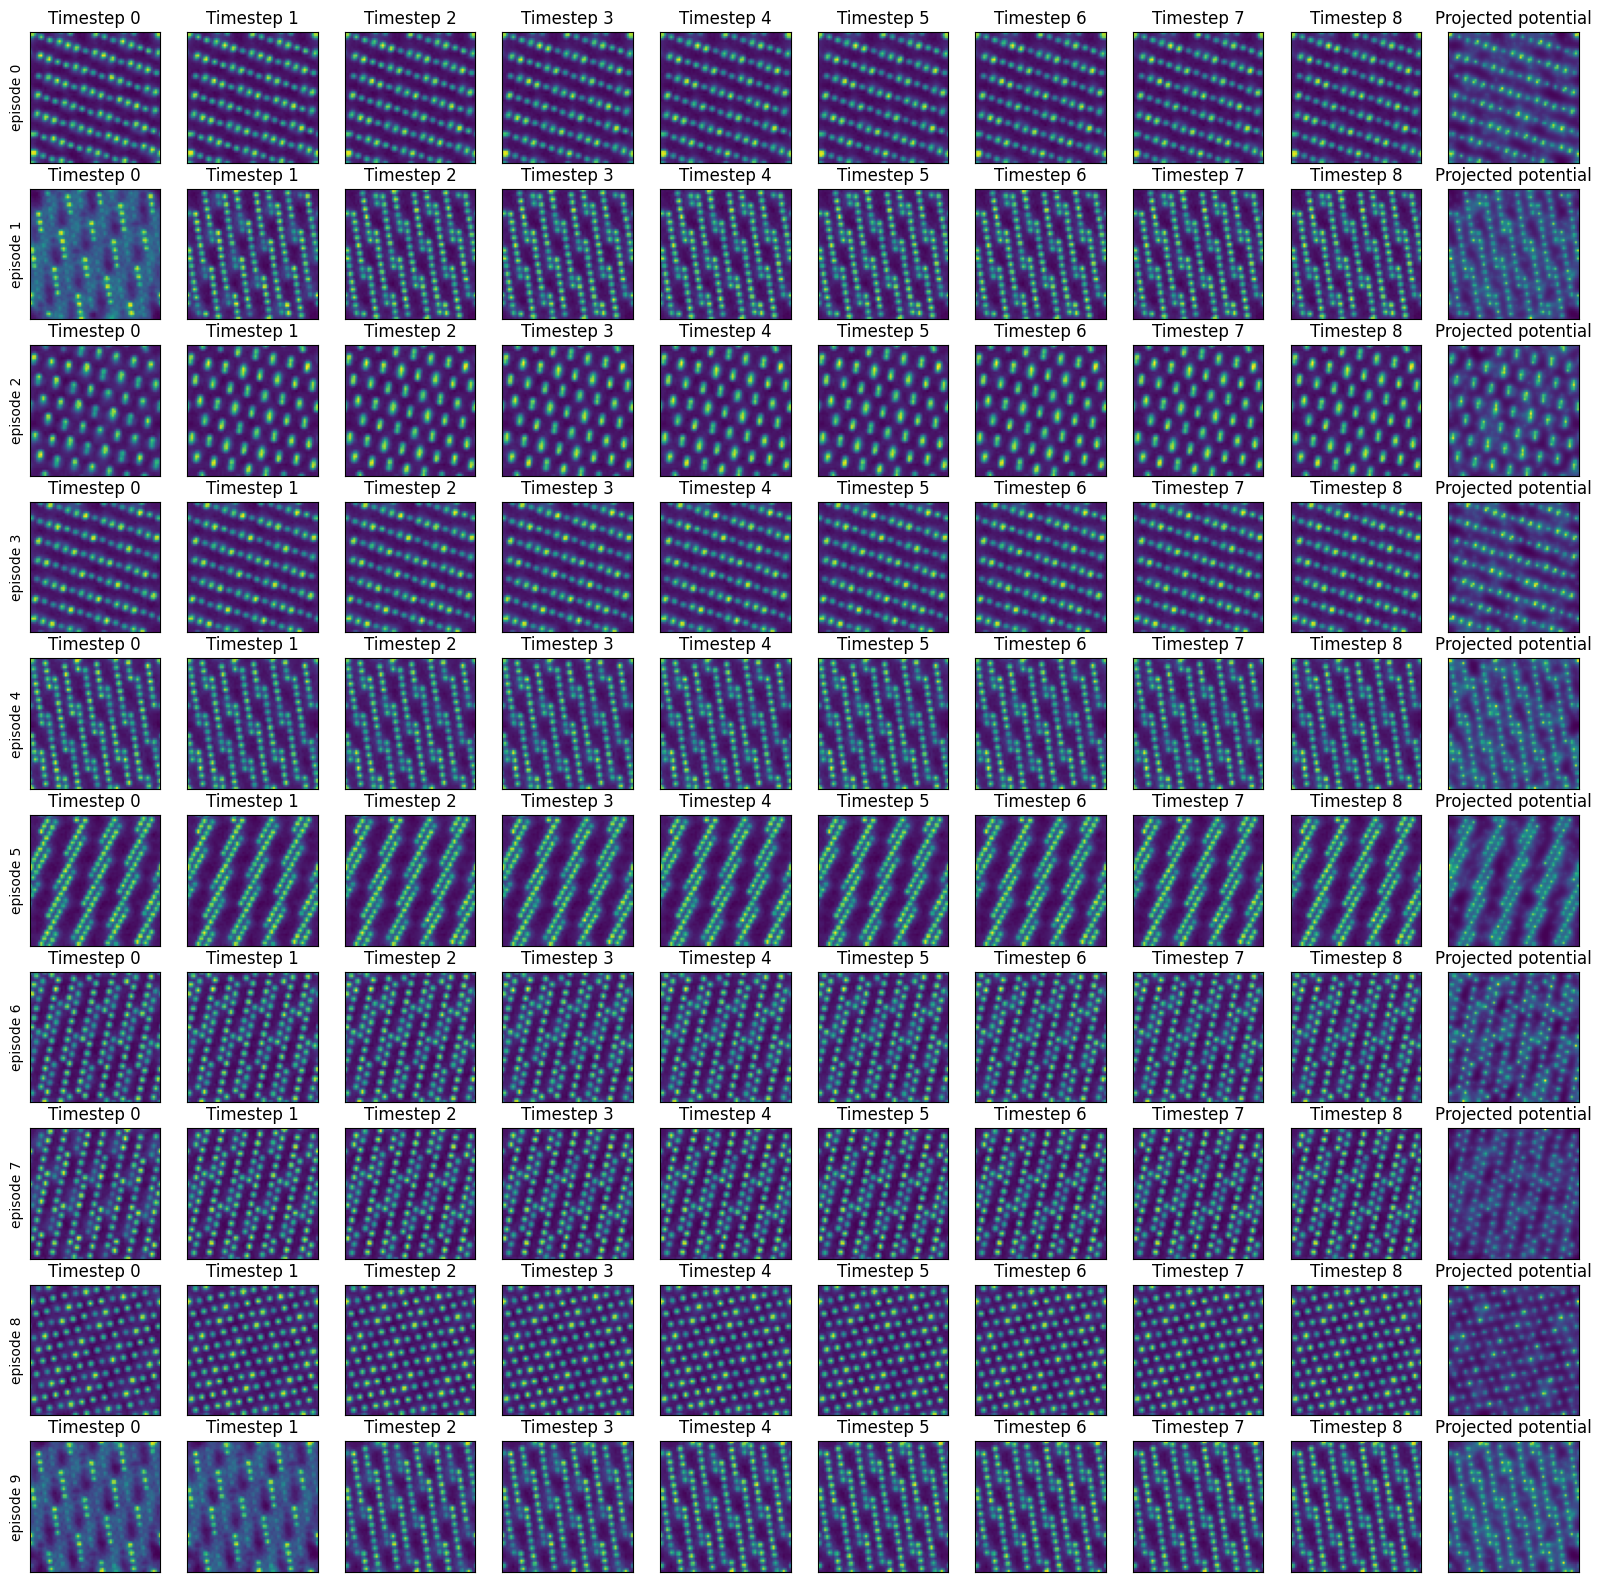

In [ ]:


load_env_temp =  DummyVecEnv([lambda: Monitor(make_env())])
base_log_dir = "logs/20251204-161325"
load_env_temp = VecNormalize(load_env_temp, norm_obs=False, norm_reward=False, clip_obs=10.0)
load_env = VecNormalize.load(f"{base_log_dir}/vec_logs.pkl", load_env_temp)
load_env.training = False

env_use = load_env #vec_env
env_use.training = False

model_load = SAC.load(f"{base_log_dir}/best_sac/best_model.zip", env = env_use, device="cuda")

model_use = model_load #model

returns = []


def _reset_env(env):
    res = env.reset()
    env.state = 45
    # Gym >=0.26 returns (obs, info); SB3 expects obs only
    if isinstance(res, tuple) and len(res) >= 1:
        return res[0]
    return res

def _step_env(env, action):
    res = env.step(action)
    # Gym >=0.26 step may return (obs, reward, terminated, truncated, info)
    if isinstance(res, tuple) and len(res) == 5:
        obs, reward, terminated, truncated, info = res
        done = bool(terminated or truncated)
        return obs, reward, done, info
    # assume old API: obs, reward, done, info
    return res

states_eps = []
rewards_eps = []
focus_met_eps = []
SSIM_eps = []
fig, ax = plt.subplots(10, 10, figsize = (20, 20))

for j in range(10):
    obs = _reset_env(env_use)
    done = False
    total = 0.0
    states = []
    focus_met = []
    rewards = []
    SSIMs = []
    i = 0
    while not done:
        action, _ = model_use.predict(obs, deterministic=True)
        obs, reward, done, info = _step_env(env_use, action)
        if j < ax.shape[0]:
            if i < ax.shape[1] - 1:
                ax[j, i].imshow(obs["images"][0][-1])
        
                if i ==0:
                    ax[j,i].set_ylabel(f"episode {j}")
                    
                ax[j,i].set_title(f"Timestep {i}")
                
                ax[j,i].set_xticks([])
                ax[j,i].set_yticks([])
        observe = obs["images"][0][0]
              
        potential_array = np.array(info[0]["potential"].array).sum(0)
        potential_array = (potential_array - potential_array.min()) / (potential_array.max() - potential_array.min()) # normalize those bs
        observe = (observe - observe.min()) / (observe.max() - observe.min())
        
        
        
        SSIM = structural_similarity(potential_array, observe, data_range=1.0)
        SSIMs.append(SSIM)
        
        i += 1
        rewards.append(reward)
        states.append(info[0]["state"])
        focus_met.append(info[0]["focus_metric"])
        total += reward
        
    ax[j, -1].imshow(potential_array)
    ax[j,-1].set_xticks([])
    ax[j,-1].set_yticks([])
    ax[j,-1].set_title("Projected potential")
    
    returns.append(total)
    SSIM_eps.append(SSIMs)
    
    rewards_eps.append(rewards)
    states_eps.append(states)
    focus_met_eps.append(focus_met)
print("Deterministic eval mean:", sum(returns)/len(returns))
# env.close()
fig.savefig("images_inference_results_1.svg")

    
# ax[0].set_ylim(-1,1)

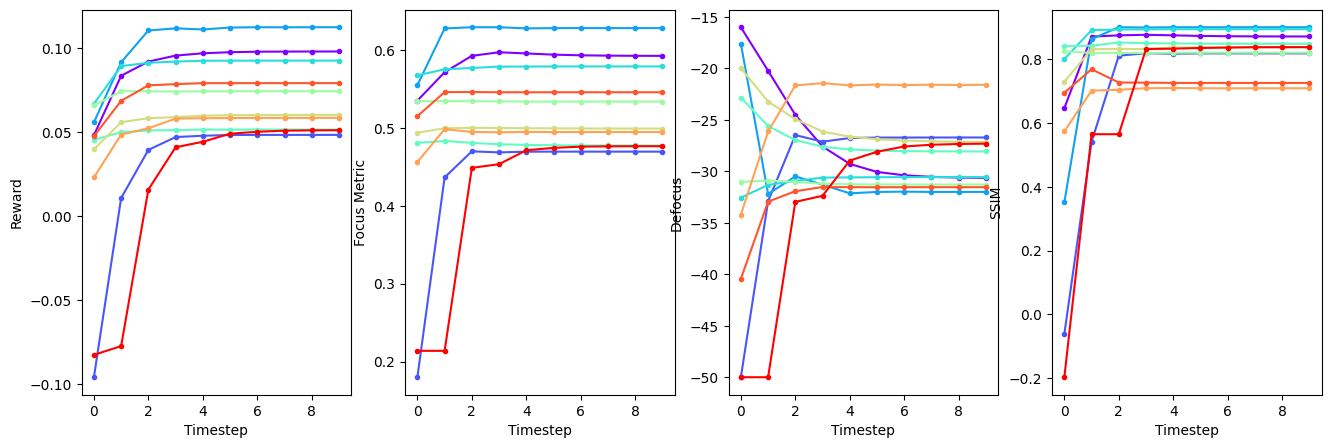

In [13]:
fig, ax = plt.subplots(1,4, figsize = (16,5))

# Use tab10 colormap for better color distinction
colors = plt.cm.rainbow(np.linspace(0, 1, 10))        

for i in range(10):
    ax[0].plot(np.array(rewards_eps[i])[0:10], marker='.', color=colors[i])
    ax[2].plot(np.array(states_eps[i])[0:10],marker='.', color=colors[i])
    ax[1].plot(np.array(focus_met_eps[i])[0:10],marker='.', color=colors[i])
    ax[3].plot(np.array(SSIM_eps[i])[0:10],marker='.', color=colors[i])
    # ax[1].plot(np.array(rewards_eps[i]))
    ax[1].set_ylabel("Focus Metric")

    ax[0].set_ylabel("Reward")
    ax[2].set_ylabel("Defocus")

    ax[3].set_ylabel("SSIM")

    ax[0].set_xlabel("Timestep")
    ax[1].set_xlabel("Timestep")
    ax[2].set_xlabel("Timestep")
    ax[3].set_xlabel("Timestep")
    
fig.savefig("inference_results_1.svg")

In [11]:
fig.savefig("inference_results.svg")

# Deployment on Tilt Series

In [ ]:
def deploy_autofocus(system, model, env, n_steps=200, center=None, device='cpu', deterministic=True, defocus = 0):
    # build env and wrap same as training (Monitor -> VecNormalize)

    vec_env = env

    # set initial state on the underlying env(s)
    # For DummyVecEnv single env, access via vec_env.envs[0].env (depending on wrappers)
    inner_env = vec_env.envs[0]  # Monitor
    # monitor wraps the real env in .env attribute
    real_env = getattr(inner_env, 'env', inner_env)

    # Prepare center coords
    center_x = (center[0] if center else None)
    center_y = (center[1] if center else None)

    # Try to set initial state on the real env directly. VecNormalize.reset(...) does
    # not accept `options=...` and may raise TypeError, so prefer direct setter.
    try:
        if hasattr(real_env, 'set_initial_state'):
            # signature in this repo: set_initial_state(center_x, center_y, system, defocus)
            real_env.set_initial_state(center_x, center_y, system, None)
        else:
            # Some envs accept reset(options=...) — try on the real env (not the VecNormalize wrapper)
            try:
                real_env.reset(options={'initial_state': {'system': system, 'center_x': center_x, 'center_y': center_y, "defocus": defocus}})
            except Exception:
                pass
    except Exception:
        # best-effort only; don't fail deploy if this doesn't work
        pass

    # Now reset the vectorized env normally (no options) to get a properly-wrapped observation
    res = vec_env.reset()
    if isinstance(res, tuple) and len(res) >= 1:
        obs = res[0]
    else:
        obs = res

    history = {'obs': [], 'actions': [], 'rewards': [], 'infos': []}

    done = False
    
    obs_step = []
    reward_step = []
    info_step = []
    for step in range(n_steps):
        action, _ = model.predict(obs, deterministic=deterministic)
        res = vec_env.step(action)
        # VecEnv.step usually returns (obs, rewards, dones, infos)
        # But some wrappers may return terminated/truncated; handle both
        if isinstance(res, tuple):
            if len(res) == 5:
                obs, reward, terminated, truncated, info = res
                done = bool(terminated or truncated)
            elif len(res) == 4:
                obs, reward, done, info = res
            else:
                # Unexpected. Try to unpack common prefix
                obs = res[0]
                reward = res[1] if len(res) > 1 else None
                done = res[2] if len(res) > 2 else False
                info = res[-1] if len(res) > 0 else {}
        else:
            # Fallback: assume nothing returned
            raise RuntimeError('Unexpected return from vec_env.step()')
        
        obs_step.append(obs)
        reward_step.append(reward)
        info_step.append(info)

        # For vectorized envs the rewards and infos are arrays/lists for each env
        # unwrap single-env case
        if isinstance(reward, (list, tuple, np.ndarray)):
            reward_val = reward[0]
        else:
            reward_val = reward

        if isinstance(info, (list, tuple)):
            info_val = info[0]
        else:
            info_val = info

        history['obs'].append(obs)
        history['actions'].append(action)
        history['rewards'].append(reward_val)
        history['infos'].append(info_val)

        if done:
            break

    # unwrap rewards, infos for single env
    return history, obs_step, reward_step, info_step


In [ ]:
best_defocuses = []
for tilt in tqdm(tilt_stack):
    history, obs_step, reward_step, info_step  = deploy_autofocus(tilt, model_load, load_env, n_steps=200, center=None, device='gpu', deterministic=True)
    defocuses = np.array([infos[0]["state"] for infos in info_step])
    focus_metrics = np.array([infos[0]["focus_metric"] for infos in info_step])
    
    best_defocus =  defocuses[focus_metrics.argmax()]
    
    best_defocuses.append(best_defocus)
    
np.save("best_defocus.npy", np.array(best_defocuses))

 46%|████▌     | 65/141 [08:05<09:25,  7.45s/it]